# Reservoir Computing Workbench
Run forecasts with `run_reservoir_forecast.py`, evaluate with `eval_forecast.py`, and plot with `plot_forecast.py`. Edit the parameters below to choose the system and reservoir settings, then run the cells in order.

In [1]:
# Setup imports and path
from pathlib import Path
import sys, json
import numpy as np

repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import run_reservoir_forecast as rcf
import eval_forecast as ef
import plot_forecast as pf
print('Repo root:', repo_root)

Repo root: /Users/krithikesh/Documents/CU/Juan-research/Github public/reservoir-computing


## Parameters
Edit these to choose system, tweak system and reservoir settings, and control training/forecast durations.

In [ ]:
# Select system and parameters
system_name = 'sprott-linz'  # 'sprott-linz' or 'lorenz'
# For sprott-linz use {'a': 0.42}; for lorenz use {'sigma': 10.0, 'rho': 28.0, 'beta': 8.0/3.0}
system_params = {'a': 0.40}  # e.g., {'rho': 30.0} for lorenz or {'a': 0.41} for sprott-linz

# Simulation times
training_time = 60.0   # seconds
forecast_time = 30.0    # seconds
dt = 0.001            # time step

# Reservoir hyperparameters
reservoir_size = 500
spectral_radius = 1.2
density = 6.0
input_scale = 0.1
bias = 1.0
lam = 1e-4
washout = 800

# Integrators
training_integrator = 'rk4'  # 'euler' or 'rk4'
truth_integrator = 'rk4'     # 'euler' or 'rk4'

# Misc
seed = 123

cfg = rcf.Config(
    system_name=system_name,
    system_params=system_params,
    training_time=training_time,
    dt=dt,
    reservoir_size=reservoir_size,
    spectral_radius=spectral_radius,
    density=density,
    input_scale=input_scale,
    bias=bias,
    lam=lam,
    washout=washout,
    truth_integrator=truth_integrator,
    training_integrator=training_integrator,
    forecast_time=forecast_time,
    seed=seed,
)
cfg

Config(system_name='sprott-linz', system_params={'a': 0.4}, training_time=60.0, dt=0.001, reservoir_size=300, spectral_radius=1.2, density=6.0, input_scale=0.1, bias=1.0, lam=0.0001, washout=800, truth_integrator='rk4', training_integrator='rk4', forecast_time=30.0, seed=123)

## Run a forecast
Trains the reservoir and produces true vs predicted trajectories.

In [22]:
results = rcf.run(cfg)
forecast = results['forecast']
print('true shape:', forecast['true'].shape, 'pred shape:', forecast['pred'].shape, 'times shape:', forecast['times'].shape)

true shape: (3, 30000) pred shape: (3, 30000) times shape: (30000,)


## Evaluate errors

In [23]:
errs = ef.evaluate_forecast_results(forecast, verbose=True)
errs

MSE dim: [0.02853172 0.02316863 0.01713273]
NRMSE dim: [0.21841422 0.18833542 0.23986142]
Total MSE: 0.022944356901394805
Total NRMSE: 0.170713387528883
Trajectory distance: 0.03568273347212624
Divergence threshold: 0.041377144758245055
Divergence time: 4.857161905396846


{'mse_dim': array([0.02853172, 0.02316863, 0.01713273]),
 'nrmse_dim': array([0.21841422, 0.18833542, 0.23986142]),
 'mse_total': 0.022944356901394805,
 'nrmse_total': 0.170713387528883,
 'trajectory_distance': 0.03568273347212624,
 'divergence_time': 4.857161905396846,
 'divergence_threshold': 0.041377144758245055}

## Plot forecast and error

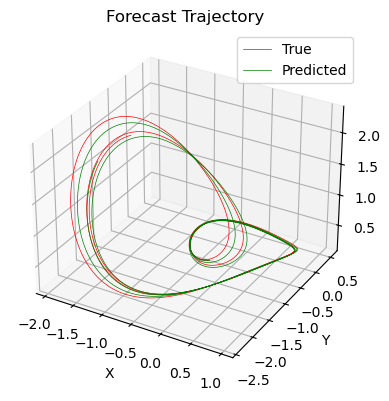

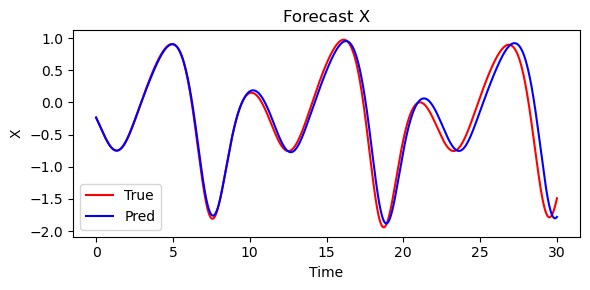

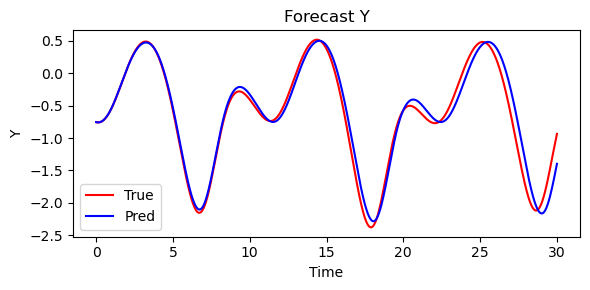

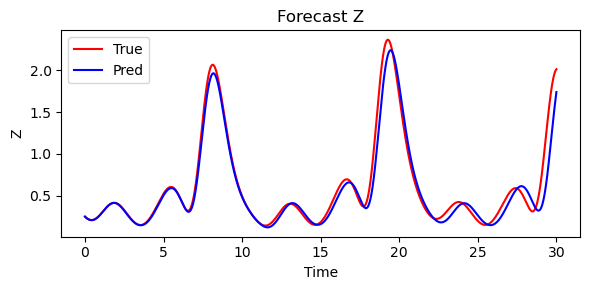

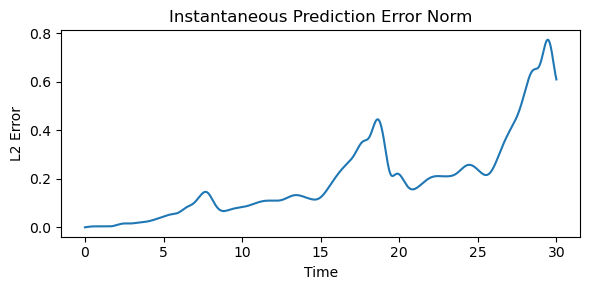

In [24]:
_ = pf.plot_all(forecast, from_time=0.0, to_time=min(30.0, float(forecast['times'][-1])), error_plot=True)

## Save and reload
Save arrays to disk and reload to evaluate/plot without retraining.

In [ ]:
from pathlib import Path
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)
base = out_dir / 'workbench_test'
rcf.save_results(str(base), results)
print('Saved to:', str(base)+'.npz', 'and', str(base)+'.json')
npz = np.load(str(base)+'.npz')
forecast_loaded = {'true': npz['true'], 'pred': npz['pred'], 'times': npz['times']}
errs_loaded = ef.evaluate_forecast_results(forecast_loaded, verbose=True)
_ = pf.plot_all(forecast_loaded, from_time=0.0, to_time=min(5.0, float(forecast_loaded['times'][-1])), error_plot=True)

## Alternate system example (Lorenz)

In [ ]:
cfg2 = rcf.Config(system_name='lorenz', forecast_time=6.0, training_time=80.0, dt=0.002, seed=7, reservoir_size=400)
results2 = rcf.run(cfg2)
fc2 = results2['forecast']
_ = ef.evaluate_forecast_results(fc2, verbose=True)
_ = pf.plot_all(fc2, from_time=0.0, to_time=min(4.0, float(fc2['times'][-1])), error_plot=True)